# CT denoising reconstructing #
---
# Part 0: Modulation import




In [11]:
import numpy as np
import pywt
import matplotlib.pyplot as plt
from sktime.datasets import load_from_tsfile

---
# Part 1: Simulated signal generation
In this part, functions how to generating the signals are demonstrated. And also the metrics to compare the denoising affect of differents are shown.

## 1. Signal generation

In [12]:
def generate_advanced_ppg(num_samples=3000, fs=100, heart_rate=60, 
                          a1=1.0000, theta1=-1.5161, b1=0.6303, 
                          a2=0.1999, theta2=0.8186, b2=1.0225):
    duration = num_samples / fs
    num_beats = duration * (heart_rate / 60.0)
    total_math_time = num_beats * 6.0
    t_math = np.linspace(0, total_math_time, num_samples)
    t_p = (t_math % 6.0) - 3.0
    pure_signal = (a1 * np.exp(-0.5 * ((t_p - theta1) / b1)**2) + 
                   a2 * np.exp(-0.5 * ((t_p - theta2) / b2)**2))
    return pure_signal



## 2. Metrics generation

In [13]:
def evaluate_performance(pure_signal, noisy_signal, denoised_signal):
    signal_power = np.sum(pure_signal**2)
    noise_power_out = np.sum((pure_signal - denoised_signal)**2)
    noise_power_in = np.sum((pure_signal - noisy_signal)**2)
    
    snr_out = 10 * np.log10(signal_power / noise_power_out) if noise_power_out != 0 else np.inf
    snr_in = 10 * np.log10(signal_power / noise_power_in) if noise_power_in != 0 else np.inf
    rmse = np.sqrt(np.mean((pure_signal - denoised_signal)**2))
    prd = np.sqrt(np.sum((pure_signal - denoised_signal)**2) / signal_power) * 100
    
    return snr_in, snr_out, rmse, prd

---
# Part 2: Algorithms design
In this part, functions with three methods: Discrete Wavelet Transform (DWT), DWT based on Crest Factor and Wavelet Packet Transform (PWT) are implemented.
## 1. Method based on Discrete Wavelet Transform 

In [14]:
def dwt_denoising_baseline(noisy_signal, wavelet='db4', level=5):
    """
    传统基准去噪法：固定层数，使用通用全局软阈值 (Universal Soft Thresholding)
    """
    signal_length = len(noisy_signal)
    max_possible = pywt.dwt_max_level(signal_length, pywt.Wavelet(wavelet).dec_len)
    actual_level = min(level, max_possible) # 防止设置的层数超过信号长度允许的极限
    
    # 1. 分解
    coeffs = pywt.wavedec(noisy_signal, wavelet, level=actual_level)
    
    # 2. 估计噪声方差 (基于第一层高频细节系数 cD1)
    sigma = np.median(np.abs(coeffs[-1])) / 0.6745
    
    # 3. 计算全局通用阈值 (Donoho Universal Threshold)
    uthresh = sigma * np.sqrt(2 * np.log(signal_length))
    
    # 4. 软阈值处理 (保留近似系数 cA 不处理)
    denoised_coeffs = [coeffs[0]]
    for i in range(1, len(coeffs)):
        denoised_coeffs.append(pywt.threshold(coeffs[i], value=uthresh, mode='soft'))
        
    # 5. 重构
    denoised_signal = pywt.waverec(denoised_coeffs, wavelet)
    return denoised_signal[:signal_length], actual_level

## 2. Method based on Discrete Wavelet Transform using crest factor

In [15]:
def calculate_crest_factor(cd):
    """Calculate Crest Factor"""
    rms = np.sqrt(np.mean(cd**2))
    if rms == 0:
        return 0
    return np.max(np.abs(cd)) / rms

def dwt_denoising_with_cf(noisy_signal, wavelet='db4', max_allowed_level=7):
    """
    DWT denoising with Crest Factor-based adaptive thresholding.
    """
    signal_length = len(noisy_signal)
    max_possible_level = min(pywt.dwt_max_level(signal_length, pywt.Wavelet(wavelet).dec_len), max_allowed_level)
    
    k_opt = 1
    for i in range(1, max_possible_level + 1):
        coeffs_temp = pywt.wavedec(noisy_signal, wavelet, level=i)
        cd_i = coeffs_temp[1] 
        cf_i = calculate_crest_factor(cd_i)
        
        if cf_i < 2.5:
            k_opt = max(1, i - 1)
            break
    else:
        k_opt = max_possible_level

    coeffs = pywt.wavedec(noisy_signal, wavelet, level=k_opt)
    cd_1 = coeffs[-1]
    cf_1 = calculate_crest_factor(cd_1)
    
    denoised_coeffs = [coeffs[0]] 
    
    for j in range(1, len(coeffs)):
        cd_j = coeffs[j]
        cf_j = calculate_crest_factor(cd_j)
        
        if cf_j >= 3.5:
            new_cd = np.zeros_like(cd_j) 
        elif 2.5 < cf_j <= 3.5:
            a = cf_j / cf_1 if cf_1 != 0 else 1
            gamma = a * np.max(np.abs(cd_j))
            new_cd = pywt.threshold(cd_j, gamma, mode='hard') 
        else:
            new_cd = cd_j # 信号为主，保留
            
        denoised_coeffs.append(new_cd)
        
    denoised_signal = pywt.waverec(denoised_coeffs, wavelet)
    return denoised_signal[:signal_length], k_opt

## 2. Method based on Wavelet Packet Transform 

In [16]:
def calculate_shannon_entropy(data):
    data_sq = data**2
    val = data_sq[data_sq > 1e-12] # 防止 log(0)
    if len(val) == 0:
        return 0
    return -np.sum(val * np.log(val))

def wpt_denoising_with_entropy(noisy_signal, wavelet='db4', max_level=4, alpha=0.5):
    """
    基于 WPT 最优基与改进混合阈值的去噪
    返回：去噪后的信号, wp树对象 (可用于可视化)
    """
    signal_length = len(noisy_signal)
    wp = pywt.WaveletPacket(data=noisy_signal, wavelet=wavelet, mode='symmetric', maxlevel=max_level)
    
    # 1. 最优基选择 (自底向上剪枝)
    for current_level in range(max_level - 1, -1, -1):
        for node in wp.get_level(current_level, 'freq'):
            if node.is_empty:
                continue
            try:
                child_a = wp[node.path + 'a']
                child_d = wp[node.path + 'd']
            except KeyError:
                continue

            entropy_parent = calculate_shannon_entropy(node.data)
            entropy_children = calculate_shannon_entropy(child_a.data) + calculate_shannon_entropy(child_d.data)

            if entropy_parent <= entropy_children:
                del wp[child_a.path]
                del wp[child_d.path]

    # 2. 计算全局阈值 (基于高频细节节点估计噪声)
    try:
        noise_coeffs = wp['d'].data
    except (KeyError, ValueError):
        # 如果不存在 'd' 节点，则回退使用原始噪声信号估计
        noise_coeffs = noisy_signal
        
    sigma = np.median(np.abs(noise_coeffs)) / 0.6745
    threshold = sigma * np.sqrt(2 * np.log(signal_length))

    # 3. 对最优基叶子节点应用改进型混合阈值
    for node in wp.get_leaf_nodes():
        if node.path == 'a' * len(node.path):
            continue # 保留最低频近似分支
            
        data = node.data
        denoised_data = np.zeros_like(data)
        
        # 混合阈值处理: y = sgn(x) * (|x| - alpha * T)
        mask = np.abs(data) >= threshold
        denoised_data[mask] = np.sign(data[mask]) * (np.abs(data[mask]) - alpha * threshold)
        
        node.data = denoised_data
        
    # 4. 重构信号
    denoised_signal = wp.reconstruct(update=False)
    return denoised_signal[:signal_length], wp

---
# Part 3: Tools for comparsion
In this part, functions for making plots are demonstrated, which makes it easier to compare and clearly showcase the results on simulation results

In [30]:
def plot_comprehensive_results(t, noisy_signal, pure_signal, 
                               denoised_base, denoised_cf, denoised_wpt, 
                               signal_type, lvl_base, lvl_cf, 
                               so_base=None, so_cf=None, so_wpt=None):
    """
    绘制四联子图，横向对比三种去噪算法的效果。
    独立封装，方便维护和重复调用。
    """
    plt.figure(figsize=(15, 11))
    
    # 💥 核心修改：下限保持原始时间的起点(t[0])，上限最大限制到 30
    x_min = t[0] 
    x_max = min(30, t[-1]) 

    # [1] Raw Data
    plt.subplot(4, 1, 1)
    plt.plot(t, noisy_signal, color='red', alpha=0.6, label='Raw Noisy Signal')
    # 这里稍微兼容了一下 6，防止信号 6 报错，同时保留你的原始 Title 格式
    if signal_type not in [5, 6]: 
        plt.plot(t, pure_signal, 'k--', label='Ground Truth')
        plt.title(f"Input Signal (AWGN + Baseline Wander)")
    else:
        plt.title(f"Real Measured PPG Signal (Type {signal_type})")
    plt.legend(loc='upper right')
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.xlim(x_min, x_max) # 💥 限制横轴: 保持下限不变，上限最大到 30

    # [2] Baseline DWT
    plt.subplot(4, 1, 2)
    plt.plot(t, noisy_signal, color='red', alpha=0.2)
    plt.plot(t, denoised_base, color='darkorange', linewidth=1.5, label=f'Baseline DWT (Level {lvl_base})')
    title_base = f"Method 1: Baseline DWT (Global Soft Thresh)"
    if so_base is not None: title_base += f" | SNR: {so_base:.2f}dB"
    plt.title(title_base)
    plt.legend(loc='upper right')
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.xlim(x_min, x_max) # 💥

    # [3] Adaptive CF-DWT
    plt.subplot(4, 1, 3)
    plt.plot(t, noisy_signal, color='red', alpha=0.2)
    plt.plot(t, denoised_cf, color='blue', linewidth=1.5, label=f'CF-DWT (Level {lvl_cf})')
    title_cf = f"Method 2: Adaptive DWT (Crest Factor)"
    if so_cf is not None: title_cf += f" | SNR: {so_cf:.2f}dB"
    plt.title(title_cf)
    plt.legend(loc='upper right')
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.xlim(x_min, x_max) # 💥

    # [4] Entropy WPT
    plt.subplot(4, 1, 4)
    plt.plot(t, noisy_signal, color='red', alpha=0.2)
    plt.plot(t, denoised_wpt, color='green', linewidth=1.5, label='WPT (Best Basis)')
    title_wpt = f"Method 3: WPT (Shannon Entropy)"
    if so_wpt is not None: title_wpt += f" | SNR: {so_wpt:.2f}dB"
    plt.title(title_wpt)
    plt.xlabel("Time (seconds)")
    plt.legend(loc='upper right')
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.xlim(x_min, x_max) # 💥

    plt.tight_layout()
    plt.show()
    

---
# Part 4: Practical implementation


Signal 1-4 are simulated signals, Signal 5 is the real PPG signal, Signal 6 is the signal we have conducted


 开始测试 Signal Type: 1
成功生成模拟测试信号 (Type 1)

[开始执行对比算法]
-> Method 1 (Baseline DWT) 完毕. 固定层数: 5
-> Method 2 (Adaptive CF-DWT) 完毕. 自适应层数: 4
-> Method 3 (Entropy WPT) 完毕. 最优基生成完毕.

=== 定量评估结果 (输入 SNR: 5.87 dB) ===
M1 (Baseline): 提升 0.25 dB | 最终 SNR: 6.12 dB | RMSE: 0.2273
M2 (Adaptive): 提升 0.61 dB | 最终 SNR: 6.49 dB | RMSE: 0.2180
M3 (WPT)     : 提升 0.65 dB | 最终 SNR: 6.52 dB | RMSE: 0.2172


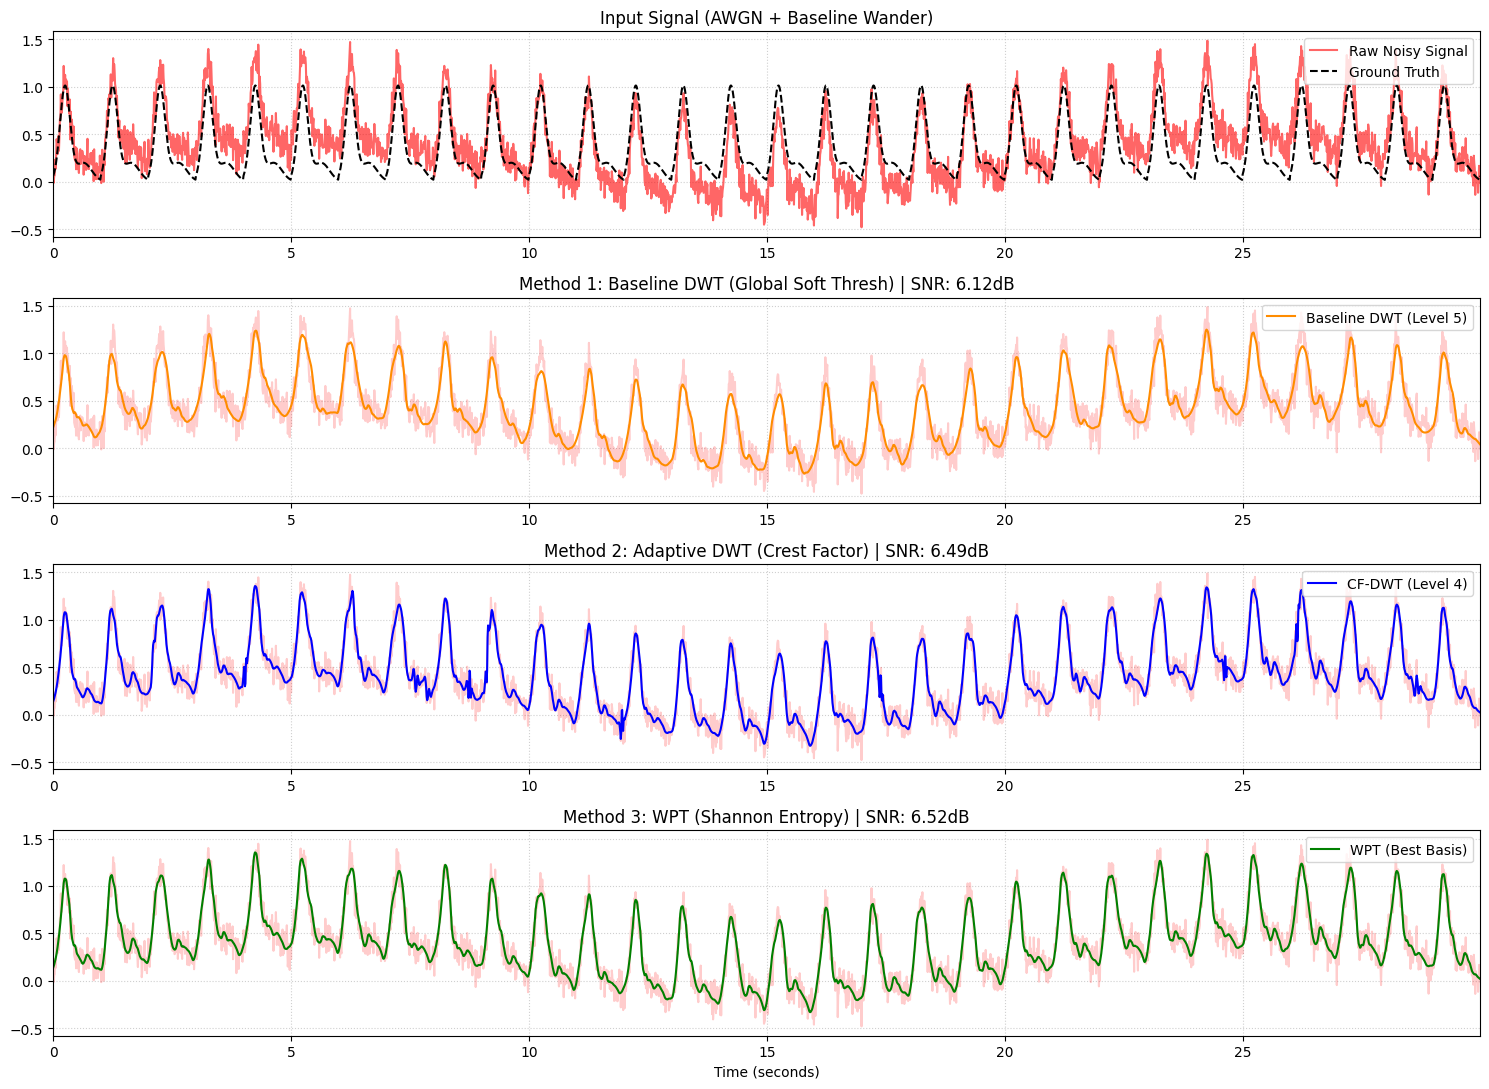


 开始测试 Signal Type: 2
成功生成模拟测试信号 (Type 2)

[开始执行对比算法]
-> Method 1 (Baseline DWT) 完毕. 固定层数: 5
-> Method 2 (Adaptive CF-DWT) 完毕. 自适应层数: 3
-> Method 3 (Entropy WPT) 完毕. 最优基生成完毕.

=== 定量评估结果 (输入 SNR: 5.81 dB) ===
M1 (Baseline): 提升 -0.34 dB | 最终 SNR: 5.47 dB | RMSE: 0.2452
M2 (Adaptive): 提升 0.49 dB | 最终 SNR: 6.30 dB | RMSE: 0.2227
M3 (WPT)     : 提升 0.37 dB | 最终 SNR: 6.18 dB | RMSE: 0.2258


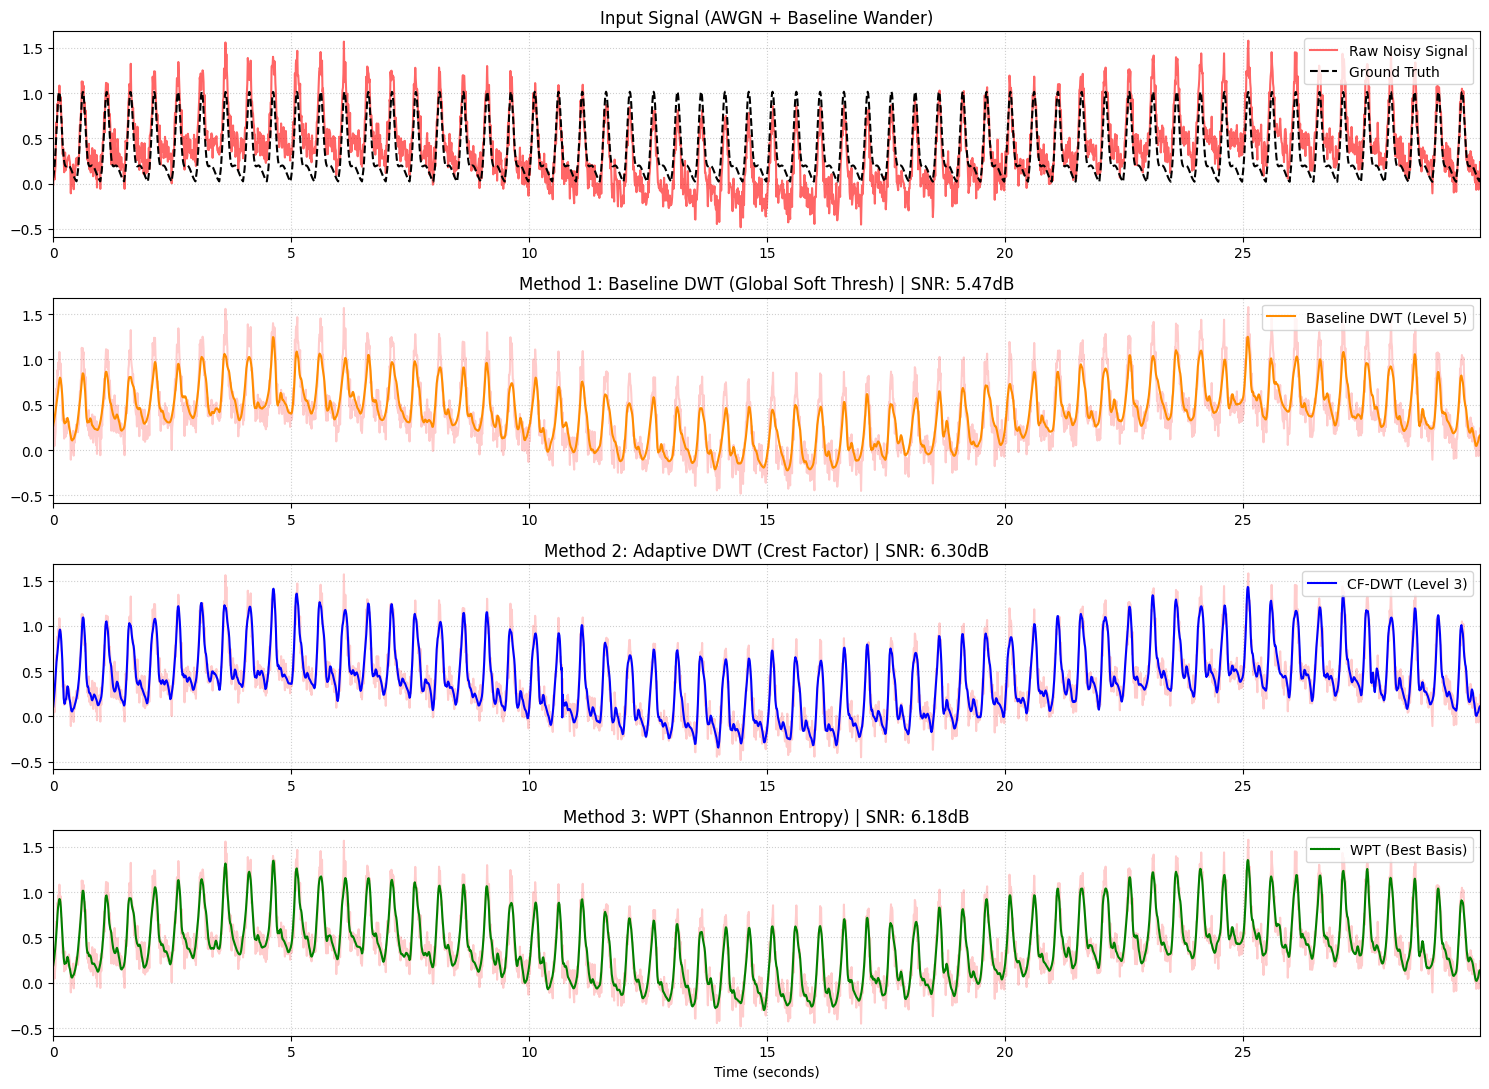


 开始测试 Signal Type: 3
成功生成模拟测试信号 (Type 3)

[开始执行对比算法]
-> Method 1 (Baseline DWT) 完毕. 固定层数: 5
-> Method 2 (Adaptive CF-DWT) 完毕. 自适应层数: 4
-> Method 3 (Entropy WPT) 完毕. 最优基生成完毕.

=== 定量评估结果 (输入 SNR: 5.40 dB) ===
M1 (Baseline): 提升 0.23 dB | 最终 SNR: 5.63 dB | RMSE: 0.2265
M2 (Adaptive): 提升 0.57 dB | 最终 SNR: 5.96 dB | RMSE: 0.2179
M3 (WPT)     : 提升 0.64 dB | 最终 SNR: 6.03 dB | RMSE: 0.2162


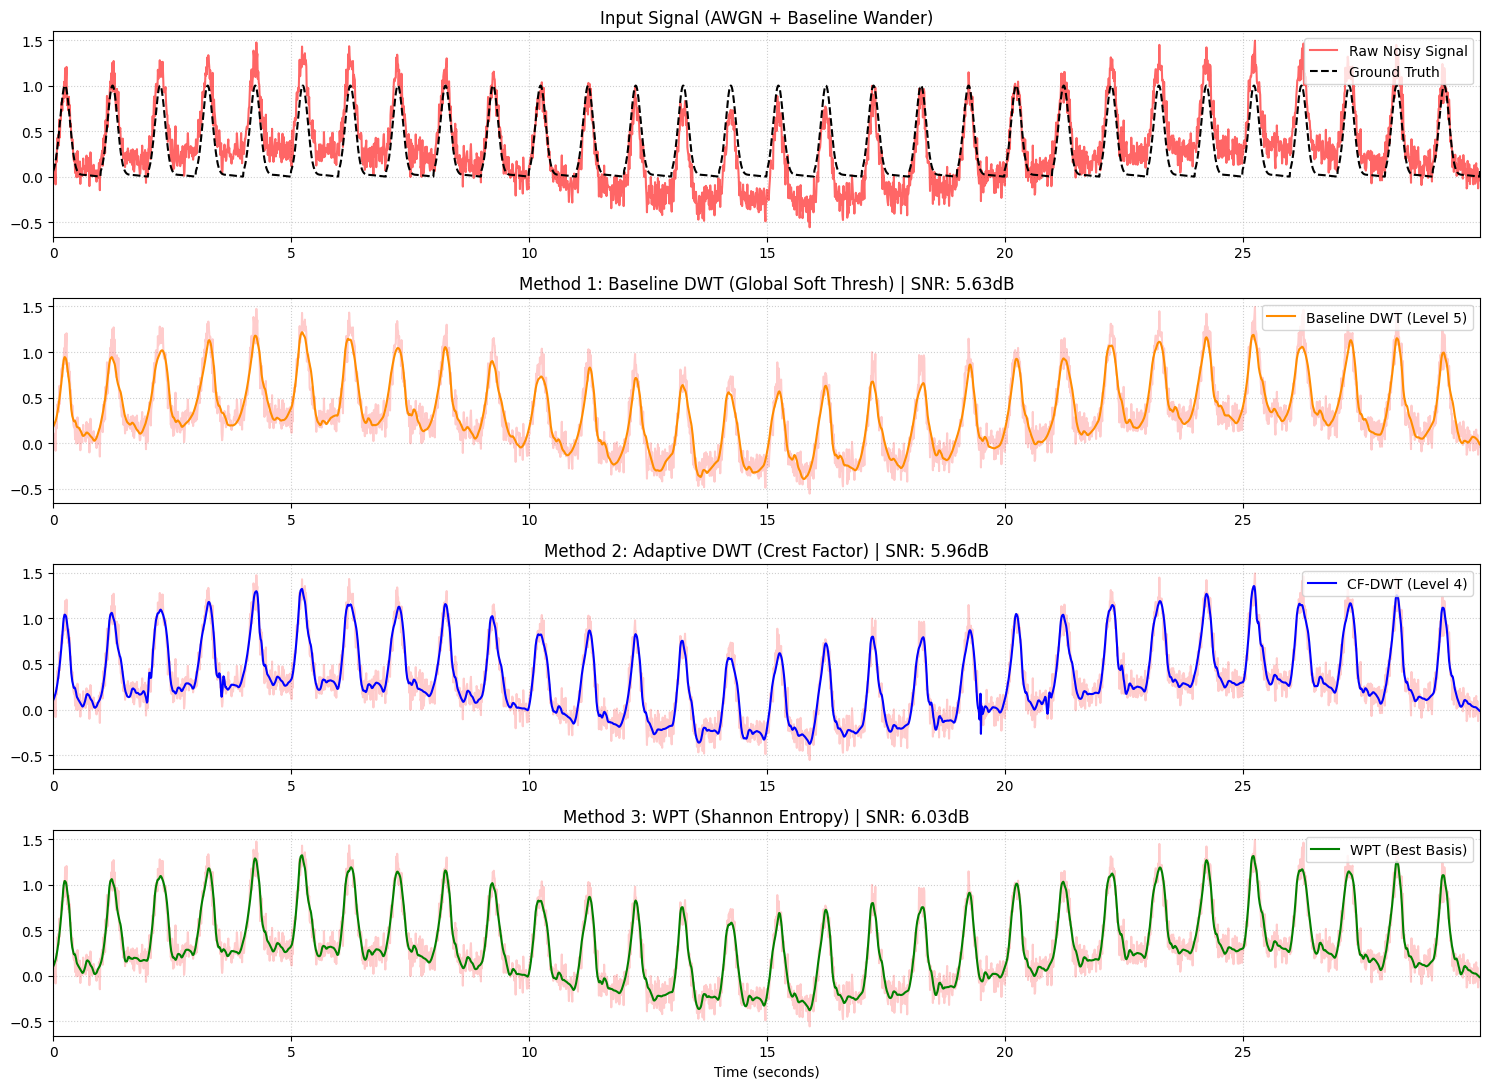


 开始测试 Signal Type: 4
成功生成模拟测试信号 (Type 4)

[开始执行对比算法]
-> Method 1 (Baseline DWT) 完毕. 固定层数: 5
-> Method 2 (Adaptive CF-DWT) 完毕. 自适应层数: 6
-> Method 3 (Entropy WPT) 完毕. 最优基生成完毕.

=== 定量评估结果 (输入 SNR: 7.83 dB) ===
M1 (Baseline): 提升 0.81 dB | 最终 SNR: 8.64 dB | RMSE: 0.2127
M2 (Adaptive): 提升 0.13 dB | 最终 SNR: 7.96 dB | RMSE: 0.2299
M3 (WPT)     : 提升 0.82 dB | 最终 SNR: 8.65 dB | RMSE: 0.2124


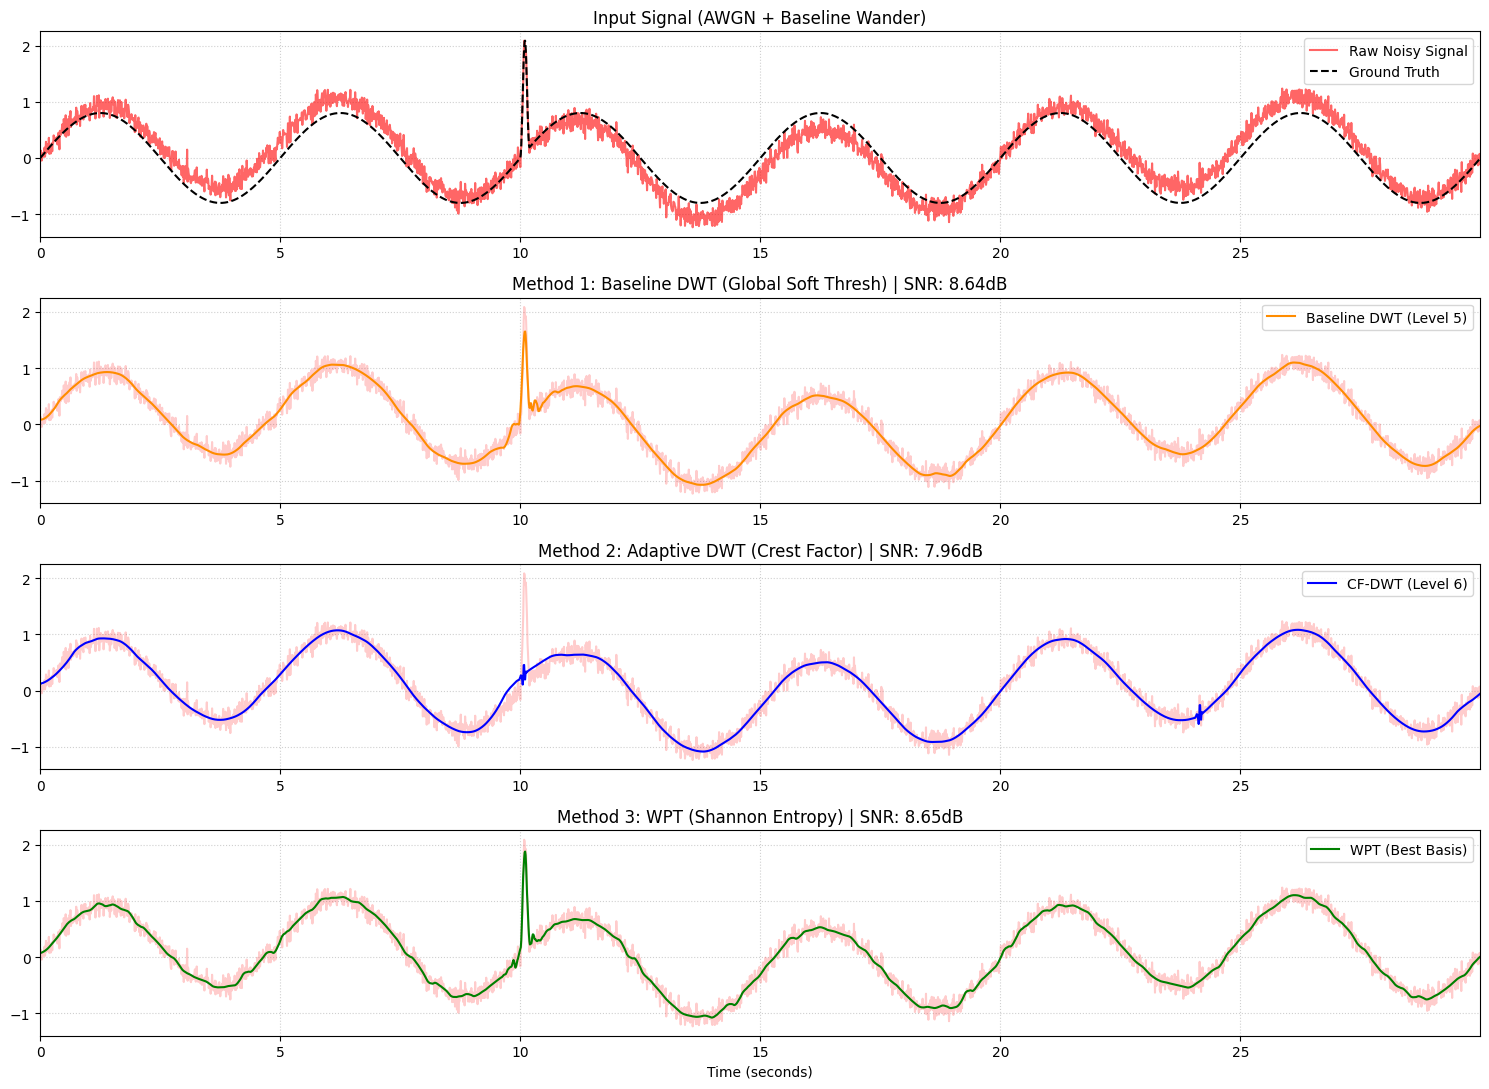


 开始测试 Signal Type: 5
成功载入实测样本(IEEE PPG)，长度: 1000 点

[开始执行对比算法]
-> Method 1 (Baseline DWT) 完毕. 固定层数: 5
-> Method 2 (Adaptive CF-DWT) 完毕. 自适应层数: 4
-> Method 3 (Entropy WPT) 完毕. 最优基生成完毕.

[实测数据模式 (Type 5)] 无 Ground Truth，请观察绘制波形比较算法优劣。


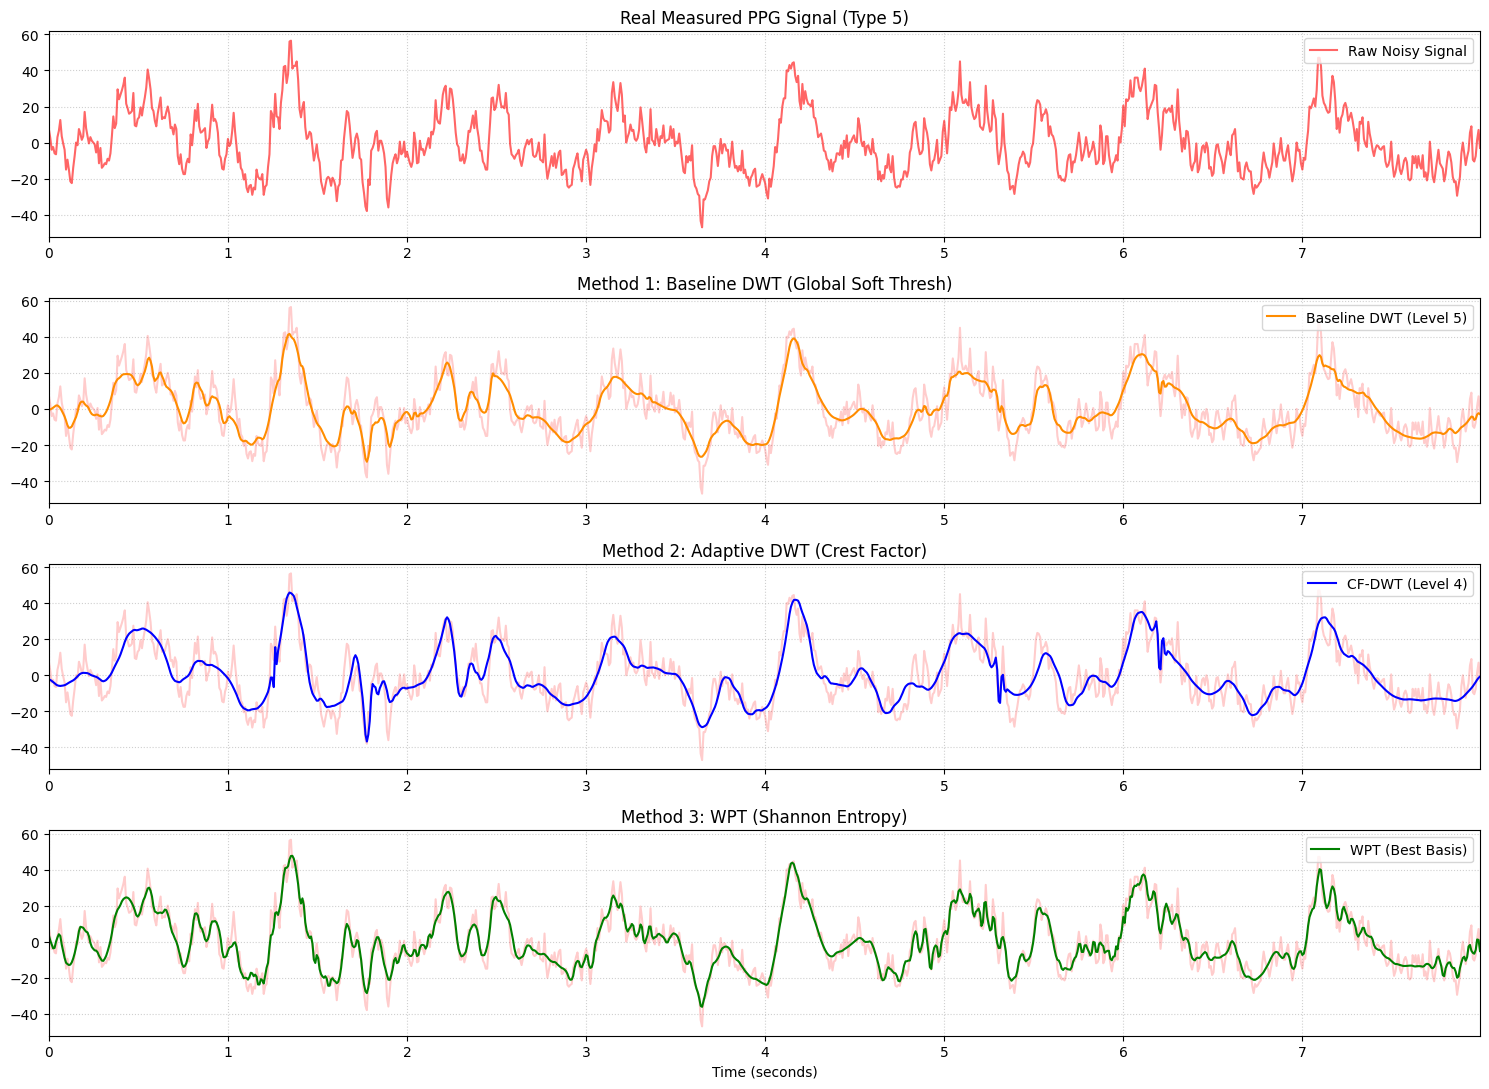


 开始测试 Signal Type: 6
信号6加载成功：时长 31.68s, 数值已放大 1E6

[开始执行对比算法]
-> Method 1 (Baseline DWT) 完毕. 固定层数: 5
-> Method 2 (Adaptive CF-DWT) 完毕. 自适应层数: 7
-> Method 3 (Entropy WPT) 完毕. 最优基生成完毕.

[实测数据模式 (Type 6)] 无 Ground Truth，请观察绘制波形比较算法优劣。


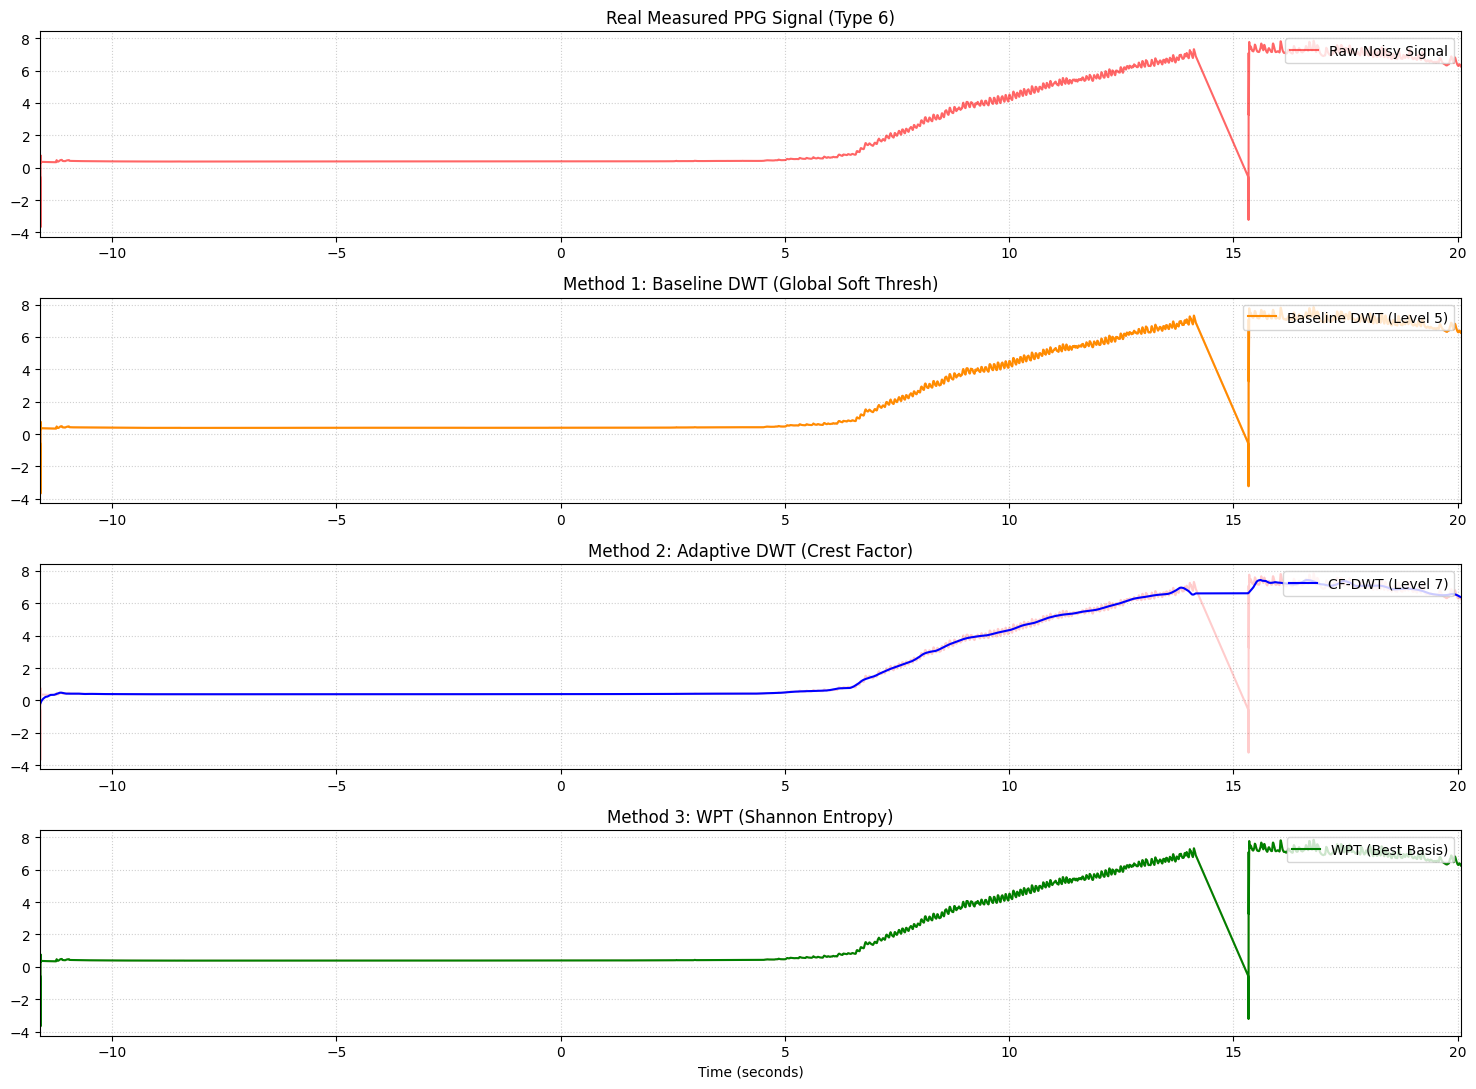

In [31]:
ts_file_path = "IEEEPPG_TEST.ts" 
sample_idx = 0           
channel_idx = 0           
wavelet_choice = 'db4'    

for i in range(1, 7): # 🌟 修改点 1：范围改到 7，使其能测试 1~6
    print(f"\n=======================================================")
    print(f" 开始测试 Signal Type: {i}")
    print(f"=======================================================")
    
    signal_type = i
    fs = 125 # 每次循环重置为 125，防止被上一次循环污染
    
    # --- 1. 载入或生成数据 ---
    if signal_type == 5:
        try:
            # 假设 load_from_tsfile 已经导入
            X, y = load_from_tsfile(ts_file_path, return_data_type="numpy3d")
            raw_data = X[sample_idx, channel_idx, :]
            noisy_signal = raw_data - np.mean(raw_data)
            num_samples = len(noisy_signal)
            t = np.arange(num_samples) / fs
            pure_signal = np.zeros(num_samples)
            print(f"成功载入实测样本(IEEE PPG)，长度: {num_samples} 点")
        except Exception as e:
            print(f"IEEE PPG实测数据读取失败({e})，回退至模拟信号(Type 1)...")
            signal_type = 1 
            fs = 100
            
    elif signal_type == 6:  
        try:
            raw_data_full = np.loadtxt("SkinG_subject1.txt")
            t = raw_data_full[:, 0]        # 👈 保持这样！不要写 t = t - t[0]
            raw_data = raw_data_full[:, 1]
            
            noisy_signal = raw_data * 1e6  # 👈 保持在滤波前放大 1E6
            # ...后续代码... 
            
            num_samples = len(noisy_signal)
            pure_signal = np.zeros(num_samples)
            print(f"信号6加载成功：时长 {t.max()-t.min():.2f}s, 数值已放大 1E6")
        except Exception as e:
            print(f"加载失败: {e}")
            # ...回退逻辑...
            signal_type = 1 
            fs = 100

    # 🌟 修改点 3：排除 5 和 6，其余均为模拟信号
    if signal_type not in [5, 6]: 
        fs = 100 # 模拟信号使用 100Hz
        num_samples = 3000
        t = np.arange(num_samples) / fs
        
        # 恢复不同 signal_type 的生成逻辑，让循环有意义
        if signal_type == 1:
            pure_signal = generate_advanced_ppg(num_samples, fs, heart_rate=60)
        elif signal_type == 2:
            pure_signal = generate_advanced_ppg(num_samples, fs, heart_rate=120) # 心率变快
        elif signal_type == 3:
            pure_signal = generate_advanced_ppg(num_samples, fs, a2=0.02) # 潮波减弱
        elif signal_type == 4:
            pure_signal = 0.8 * np.sin(2 * np.pi * 0.2 * t)
            pure_signal[1000:1020] += 2.0 * np.hanning(20) # 模拟运动伪影突变
        else:
            pure_signal = generate_advanced_ppg(num_samples, fs)
        
        np.random.seed(42 + i) # 每次循环加点不同的噪声
        noise = np.random.normal(0, 0.1, num_samples)
        baseline_wander = 0.3 * np.sin(2 * np.pi * 0.05 * t)
        noisy_signal = pure_signal + noise + baseline_wander
        print(f"成功生成模拟测试信号 (Type {signal_type})")

    # --- 2. 运行三种对比算法 ---
    print("\n[开始执行对比算法]")
    # Method 1
    denoised_base, lvl_base = dwt_denoising_baseline(noisy_signal, wavelet=wavelet_choice, level=5)
    print(f"-> Method 1 (Baseline DWT) 完毕. 固定层数: {lvl_base}")

    # Method 2
    denoised_cf, lvl_cf = dwt_denoising_with_cf(noisy_signal, wavelet=wavelet_choice)
    print(f"-> Method 2 (Adaptive CF-DWT) 完毕. 自适应层数: {lvl_cf}")

    # Method 3
    # 💥 这里的修复关键：加上 `, _` 解包，丢弃小波树对象 wp 💥
    denoised_wpt, _ = wpt_denoising_with_entropy(noisy_signal, wavelet=wavelet_choice, max_level=4)
    print("-> Method 3 (Entropy WPT) 完毕. 最优基生成完毕.")

    # --- 3. 计算指标与可视化 ---
    so_base, so_cf, so_wpt = None, None, None

    # 🌟 修改点 4：排除 5 和 6 (实测数据不计算 SNR)
    if signal_type not in [5, 6]: 
        si, so_base, rm_base, _ = evaluate_performance(pure_signal, noisy_signal, denoised_base)
        _,  so_cf,   rm_cf,   _ = evaluate_performance(pure_signal, noisy_signal, denoised_cf)
        _,  so_wpt,  rm_wpt,  _ = evaluate_performance(pure_signal, noisy_signal, denoised_wpt)
        
        print("\n=== 定量评估结果 (输入 SNR: {:.2f} dB) ===".format(si))
        print("M1 (Baseline): 提升 {:.2f} dB | 最终 SNR: {:.2f} dB | RMSE: {:.4f}".format(so_base-si, so_base, rm_base))
        print("M2 (Adaptive): 提升 {:.2f} dB | 最终 SNR: {:.2f} dB | RMSE: {:.4f}".format(so_cf-si, so_cf, rm_cf))
        print("M3 (WPT)     : 提升 {:.2f} dB | 最终 SNR: {:.2f} dB | RMSE: {:.4f}".format(so_wpt-si, so_wpt, rm_wpt))
    else:
        print(f"\n[实测数据模式 (Type {signal_type})] 无 Ground Truth，请观察绘制波形比较算法优劣。")
    
    # 💥 直接把滤波算出来的原始变量扔进画图函数即可，不用再乘 1e6 了！
    plot_comprehensive_results(t, noisy_signal, pure_signal, 
                               denoised_base, denoised_cf, denoised_wpt, 
                               signal_type, lvl_base, lvl_cf, 
                               so_base, so_cf, so_wpt)